In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
import nibabel as nb
from matplotlib.cm import ScalarMappable
import pandas as pd
import sys
from scipy.stats import ttest_rel, ttest_1samp
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_surf, plot_avg_activation

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


In [2]:
H = 'L'
rois = gl.rois['ROI']
experiment = 'smp2'
glm = 12

# BOLD response aligned to cue presentation (Fig. 2b)

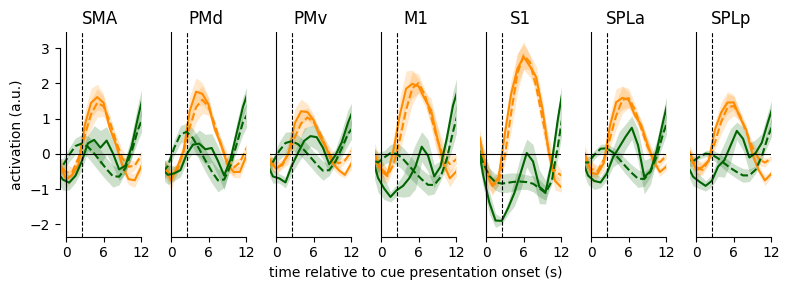

In [3]:
hrf = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', 'hrf.tsv'), sep='\t')
hrf_melt = hrf.melt(id_vars=['roi', 'Hem', 'time', 'kind', 'GoNogo'], value_vars=[str(sn) for sn in [102, 103, 104, 105, 106, 107, 108, 109]], var_name='sn', value_name='BOLD')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 3))

for r, roi in enumerate(rois):
    ax = axs[r]
    data = hrf_melt[(hrf_melt.Hem==H) & (hrf_melt.roi==roi)]
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='go') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', ls='--', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='adj')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', err_kws={'linewidth': 0})
    sb.lineplot(data=data[(data.GoNogo=='nogo') & (data.kind=='hat')], ax=ax, x='time', y='BOLD', errorbar='se', color='darkgreen', ls='--', err_kws={'linewidth': 0})
    
    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(2.5, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r == 0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-1, 3)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-1, 12))
    ax.set_xlabel(None)
    #ax.set_ylim((-3, 3.6))

    ax.set_title(rois[r])

ax.legend(frameon=False) #, bbox_to_anchor=(1, -.1), loc='upper right', )

axs[0].set_ylabel('activation (a.u.)')
axs[3].set_xlabel('time relative to cue presentation onset (s)')
#fig.suptitle(f'Average BOLD timeseries')
fig.tight_layout()

plt.show()

# Cortical activation during preparation (Fig. 2c)

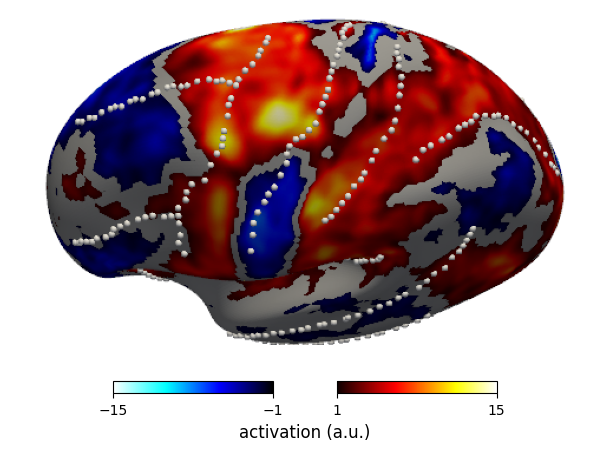

In [4]:
cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)

dtype = 'con'
thresh = 1
vmin, vmax = -15, 15

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.surfDir, f'glm{glm}.con.plan-exec.smooth.dscalar.nii'))
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)

cold_half = LinearSegmentedColormap.from_list("cold_half", combined[:128])
hot_half = LinearSegmentedColormap.from_list("hot_half", combined[128:])

neg_norm = Normalize(vmin=vmin, vmax=-thresh)
sm_neg = ScalarMappable(norm=neg_norm, cmap=cold_half)
cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

pos_norm = Normalize(vmin=thresh, vmax=vmax)
sm_pos = ScalarMappable(norm=pos_norm, cmap=hot_half)
cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

# Cortical activation during execution (Fig. 2c)

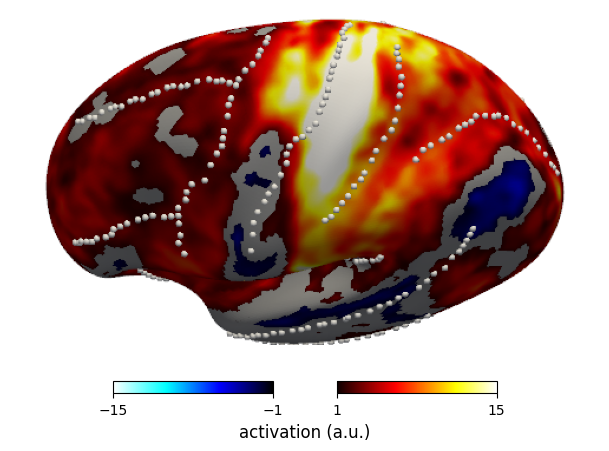

In [5]:
fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, cifti, H, cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)

cax_neg = fig.add_axes([0.2, 0.1, 0.25, 0.025])
cbar_neg = fig.colorbar(sm_neg, ax=ax, cax=cax_neg, fraction=0.03, pad=0.02, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])
fig.supxlabel('activation (a.u.)', y=.001)

cax_pos = fig.add_axes([0.55, 0.1, 0.25, 0.025])
cbar_pos = fig.colorbar(sm_pos, ax=ax, cax=cax_pos, fraction=0.03, pad=0.08, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])
plt.subplots_adjust(left=0, right=1, bottom=.2, top=.9)

plt.show()

# Cortical activation across ROI

KeyError: '100-0%      '

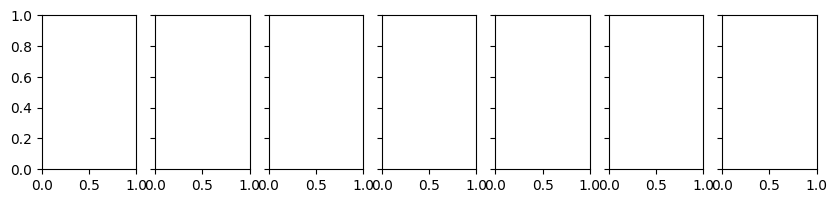

In [6]:
df_con = pd.read_csv(os.path.join('data', 'univariate_activation', 'ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(10, 2))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    tval, pval = ttest_rel(exec, plan)
    print(f'planning vs. execution: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(plan, 0, alternative='two-sided')
    print(f'planning vs. 0: tval={tval}, pval={pval}')
    tval, pval = ttest_1samp(exec, 0)
    print(f'execution vs. 0: tval={tval}, pval={pval}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()